In [1]:
import numpy as np
from scipy.stats import ks_2samp
from scipy import stats
import matplotlib.pyplot as plt
import h5py
import illustris_python as il
import sys
sys.path.append('../py_files/')
#import weights
import control_sample as control
import BRAHMA_python as il_brahma
from tqdm import tqdm
sys.path.append('/home/pranavsatheesh/arepo_package/')
import arepo_package as arepo

In [2]:
import os
tex_path = '/apps/texlive/2023/bin/x86_64-linux/'
os.environ['PATH'] += os.pathsep + tex_path

In [3]:
import scienceplots
plt.style.use('science')

In [4]:
#TNG merger files
merger_file_path='/home/pranavsatheesh/host_galaxies/data/merger_files'
minN_values = [0,0,1000,1]
merger_file_1bh = merger_file_path + f'/galaxy-mergers_TNG50-1_gas-{minN_values[0]:03d}_dm-{minN_values[1]:03d}_star-{minN_values[2]:03d}_bh-{minN_values[3]:03d}.hdf5'
fmergers_TNG50 = h5py.File(merger_file_1bh, 'r')
fmergers_TNG50.attrs['HubbleParam']

0.6774

In [5]:
fmergers_TNG50.keys()

<KeysViewHDF5 ['InfallMassRatio', 'ProgMassRatio', 'ProgMassRatio_mod', 'SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloCM', 'SubhaloGrNr', 'SubhaloHalfmassRadType', 'SubhaloLenType', 'SubhaloMassInHalfRadType', 'SubhaloMassInRadType', 'SubhaloMassType', 'SubhaloPos', 'SubhaloSFR', 'SubhaloVel', 'SubhaloVelDisp', 'fpMass', 'fpMass_mod', 'fpMasshistory', 'fpinfallMass', 'fpsnaphistory', 'npMass', 'npMass_mod', 'npMasshistory', 'npinfallMass', 'npsnaphistory', 'shids_subf', 'shids_tree', 'snaps', 'time']>

In [6]:
basePath ='/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/'
brahma_sims = ['SM5_DFD_3_TNG','SM5_LW10_DFD_3_TNG']
brahma_sim_paths = [basePath + sim + '/' for sim in brahma_sims]
merger_file_loc='/home/pranavsatheesh/host_galaxies/data/merger_files'
minN_values = [0,0,10,1]
merger_file_names = [f'galaxy-mergers_brahma_{sim}_gas-{minN_values[0]:03d}_dm-{minN_values[1]:03d}_star-{minN_values[2]:03d}_bh-{minN_values[3]:03d}.hdf5' for sim in brahma_sims]
merger_file_paths = [merger_file_loc + '/' + name for name in merger_file_names]
fmergers_brahma = [h5py.File(path, 'r') for path in merger_file_paths]
brahma_sm5 = fmergers_brahma[0]
brahma_sm5_lw10 = fmergers_brahma[1]
brahma_snapshots,brahma_redshifts = arepo.get_snapshot_redshift_correspondence(brahma_sim_paths[0])

In [7]:
brahma_snapshots

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32])

In [8]:
np.arange(0,100,1)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [9]:
h = fmergers_brahma[0].attrs['hubbleParam']                                   

In [10]:
fmergers_brahma[0].keys()

<KeysViewHDF5 ['ProgMassRatio', 'SubhaloLenType', 'fpMass', 'npMass', 'shids_subf', 'shids_tree', 'snaps']>

## A lot of BHs ?

In [11]:
NBH_mergers = brahma_sm5['SubhaloLenType'][:,5,2]
Snapshot_mergers = brahma_sm5['snaps'][:,2]
z_mergers = brahma_redshifts[Snapshot_mergers]
Subhaloid_mergers = brahma_sm5['shids_subf'][:,2]

In [12]:
def plot_Nbhs(ax,brahma_obj):
    NBH_mergers = brahma_obj['SubhaloLenType'][:,5,2]
    Snapshot_mergers = brahma_obj['snaps'][:,2]
    z_mergers = brahma_redshifts[Snapshot_mergers]
    Subhaloid_mergers = brahma_obj['shids_subf'][:,2]
    # Select a few redshift bins
    z_bins = np.array([0, 1, 3, 5])
    colors = ['r', 'g', 'b', 'm']

    for i in range(len(z_bins)-1):
        mask = (z_mergers >= z_bins[i]) & (z_mergers < z_bins[i+1])
        ax.hist(NBH_mergers[mask], bins=20, alpha=0.6, 
            label=f'z = {z_bins[i]}-{z_bins[i+1]}', color=colors[i], histtype='step')
        ax.set_xlabel('Number of BHs in galaxy merger remnant')
        ax.set_ylabel('Frequency')

    return ax

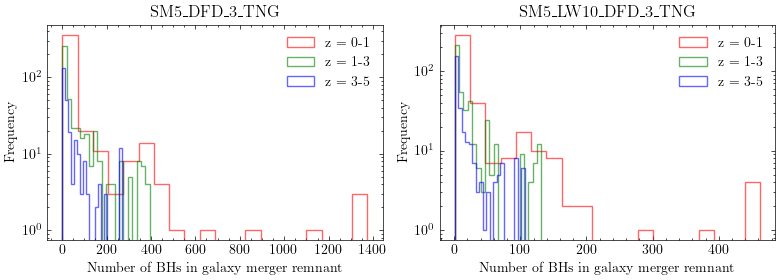

In [13]:
fig,axes = plt.subplots(1,2,figsize=(8,3))
plot_Nbhs(axes[0],brahma_sm5)
axes[0].legend()
axes[0].set_yscale('log')
axes[0].set_title('SM5_DFD_3_TNG')

plot_Nbhs(axes[1],brahma_sm5_lw10)
axes[1].legend()
axes[1].set_yscale('log')
axes[1].set_title('SM5_LW10_DFD_3_TNG')

plt.tight_layout()

In [14]:
basePath ='/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/'
brahma_sm5_lw10_lowspin_rich_path = basePath + 'SM5_LW10_LOWSPIN_RICH_DFD_3_TNG/'

In [15]:
brahma_snapshots,brahma_redshifts = arepo.get_snapshot_redshift_correspondence(brahma_sm5_lw10_lowspin_rich_path)

In [16]:
brahma_redshifts

array([2.50484387e+01, 2.39609608e+01, 2.30324872e+01, 2.20291718e+01,
       2.09634266e+01, 2.00464910e+01, 1.89776156e+01, 1.79630246e+01,
       1.69999610e+01, 1.60050415e+01, 1.49891732e+01, 1.40339921e+01,
       1.30025453e+01, 1.19802133e+01, 1.09756433e+01, 9.99659047e+00,
       9.00233985e+00, 8.01217295e+00, 7.00541705e+00, 6.01075740e+00,
       4.99593347e+00, 4.00794511e+00, 3.00813107e+00, 2.00202814e+00,
       1.49551217e+00, 9.97294226e-01, 7.00106354e-01, 5.03047523e-01,
       3.99926965e-01, 2.97717685e-01, 1.97284182e-01, 9.94018026e-02,
       2.22044605e-16])

In [17]:
z_bins = np.array([0, 1, 3, 5])
#corresponding snapshots for the redshift bins
snapshot_bins = []
for i in range(len(z_bins)-1):
    zbin_left = np.argmin(np.abs(brahma_redshifts - z_bins[i]))
    zbin_right = np.argmin(np.abs(brahma_redshifts - z_bins[i+1]))
    snap_left = brahma_snapshots[zbin_left]
    snap_right = brahma_snapshots[zbin_right]
    snapshot_bins.append((snap_left, snap_right))

print("Redshift bins:", z_bins)
print("Corresponding snapshot bins:", snapshot_bins)

Redshift bins: [0 1 3 5]
Corresponding snapshot bins: [(32, 25), (25, 22), (22, 20)]


In [18]:
Nbh_mergers_lw10_lowspin_rich = []
Snapshot_mergers_lw10_lowspin_rich = []
Subhaloid_mergers_lw10_lowspin_rich = []
z_mergers_lw10_lowspin_rich = []

for i in range(len(snapshot_bins)):
    snap_left, snap_right = snapshot_bins[i]
    Nbh_i = []
    Snap_i = []
    Subhaloid_i = []
    z_i = []
    for snap in range(snap_right,snap_left+1,1):
        print(f"Processing snapshot {snap} for redshift bin {z_bins[i]}-{z_bins[i+1]}...")
        sub_lentype = il_brahma.groupcat.loadSubhalos_postprocessed(brahma_sm5_lw10_lowspin_rich_path,snapNum=snap,fields=['SubhaloLenType'])
        Ngas = sub_lentype[:,0]
        Ndm = sub_lentype[:,1]
        Nstar = sub_lentype[:,4]
        Nbh = sub_lentype[:,5]
        idx = np.where((Ngas >= 0) & (Ndm >= 0) & (Nstar >=10) & (Nbh >= 1))[0]
        print("Number of satisfying subhalos in this snapshot:", len(idx))
        Nbh_i.extend(Nbh[idx])
        Snap_i.extend([snap]*len(idx))
        Subhaloid_i.extend(idx)
        z_i.extend([brahma_redshifts[snap]]*len(idx))
    Nbh_mergers_lw10_lowspin_rich.append(Nbh_i)
    Snapshot_mergers_lw10_lowspin_rich.append(Snap_i)
    Subhaloid_mergers_lw10_lowspin_rich.append(Subhaloid_i)
    z_mergers_lw10_lowspin_rich.append(z_i)
    

Processing snapshot 25 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 212
Processing snapshot 26 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 193
Processing snapshot 27 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 183
Processing snapshot 28 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 174
Processing snapshot 29 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 170
Processing snapshot 30 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 162
Processing snapshot 31 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 159
Processing snapshot 32 for redshift bin 0-1...
Number of satisfying subhalos in this snapshot: 156
Processing snapshot 22 for redshift bin 1-3...
Number of satisfying subhalos in this snapshot: 308
Processing snapshot 23 for redshift bin 1-3...
Number of satisfying subhalos in this snapshot: 264
Processing

Text(0.5, 0, 'Number of BHs in subhalos')

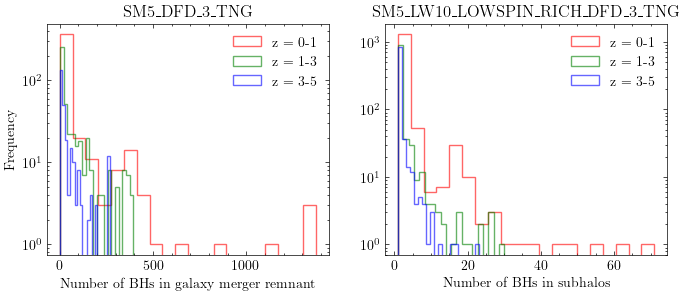

In [19]:
fig,axes = plt.subplots(1,2,figsize=(8,3))
plot_Nbhs(axes[0],brahma_sm5)
axes[0].legend()
axes[0].set_yscale('log')
axes[0].set_title('SM5_DFD_3_TNG')

colors = ['r', 'g', 'b', 'm']
for i in range(len(z_bins)-1):
    axes[1].hist(Nbh_mergers_lw10_lowspin_rich[i], bins=20, alpha=0.6, 
        label=f'z = {z_bins[i]}-{z_bins[i+1]}', histtype='step',color=colors[i])
axes[1].legend()
axes[1].set_yscale('log')
axes[1].set_title('SM5_LW10_LOWSPIN_RICH_DFD_3_TNG')
axes[1].set_xlabel('Number of BHs in subhalos')

In [20]:
#find where the number of BHs in the merger remnant is greater than 100
find_ix_nbh_gtr_100 = np.where(NBH_mergers>100)[0]
snapshots_nbh_gtr_100 = Snapshot_mergers[find_ix_nbh_gtr_100]
redshifts_nbh_gtr_100 = brahma_redshifts[snapshots_nbh_gtr_100]
subhaloids_nbh_gtr_100 = fmergers_brahma['shids_subf'][:,2][find_ix_nbh_gtr_100]

TypeError: list indices must be integers or slices, not str

In [ ]:
for i in range(4):
    index = i
    print("Snap:", snapshots_nbh_gtr_100[index], "Redshift:", redshifts_nbh_gtr_100[index], "Subhalo ID:", subhaloids_nbh_gtr_100[index], "Number of BHs in merger remnant:", NBH_mergers[find_ix_nbh_gtr_100[index]])

Snap: 32 Redshift: 2.220446049250313e-16 Subhalo ID: 0 Number of BHs in merger remnant: 1374
Snap: 25 Redshift: 0.9972942257819404 Subhalo ID: 2384 Number of BHs in merger remnant: 428
Snap: 24 Redshift: 1.4955121664955557 Subhalo ID: 1004 Number of BHs in merger remnant: 394
Snap: 24 Redshift: 1.4955121664955557 Subhalo ID: 1004 Number of BHs in merger remnant: 394


In [ ]:
subhalo_data = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=32,fields=['SubhaloLenType','SubhaloMassType','SubhaloBHMass','SubhaloHalfmassRadType','SubhaloGrNr'])
groups_data = il_brahma.groupcat.loadHalos_postprocessed(basePath, snapNum=32, fields=['GroupLen', 'GroupPos','GroupFirstSub'])

In [ ]:
subhalo_id = 0
group_id = subhalo_data['SubhaloGrNr'][subhalo_id]
subhalos_in_group = np.where(subhalo_data['SubhaloGrNr'] == group_id)[0]

In [ ]:
# Find the most massive (central) subhalo
masses = np.sum(subhalo_data['SubhaloMassType'][subhalos_in_group], axis=1)
central_subhalo_id = subhalos_in_group[np.argmax(masses)]

if subhalo_id == central_subhalo_id:
    print(f"Subhalo {subhalo_id} is the CENTRAL (main) subhalo")
else:
    print(f"Subhalo {subhalo_id} is a SATELLITE subhalo")
    print(f"Central subhalo in this group is: {central_subhalo_id}")

Subhalo 0 is the CENTRAL (main) subhalo


In [ ]:
def check_if_subhalo_is_central(snap_num, subhalo_id):
    groups_first_sub = il_brahma.groupcat.loadHalos_postprocessed(basePath, snapNum=snap_num, fields=['GroupFirstSub'])
    subhalo_grnr = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=snap_num,fields=['SubhaloGrNr'])
    group_id = subhalo_grnr[subhalo_id]
    central_subhalo_id = groups_first_sub[group_id]
    is_central = subhalo_id == central_subhalo_id
    return is_central

In [ ]:
check_if_subhalo_is_central(Snapshot_mergers[0], Subhaloid_mergers[0])

True

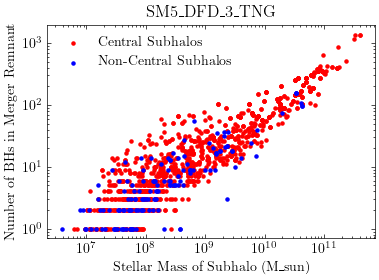

In [ ]:
subhalo_stellar_mass_central= []
NBH_mergers_central = []
subhalo_stellar_mass_non_central = []
NBH_mergers_non_central = []

for i in range(len(Snapshot_mergers)):
    stellar_mass_nbh = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=Snapshot_mergers[i],fields=['SubhaloMassType'])
    stellar_mass_nbh = stellar_mass_nbh[Subhaloid_mergers[i],4] * 1e10 / h
    is_central = check_if_subhalo_is_central(Snapshot_mergers[i], Subhaloid_mergers[i])

    if is_central:
        subhalo_stellar_mass_central.append(stellar_mass_nbh)
        NBH_mergers_central.append(NBH_mergers[i])
    else:
        subhalo_stellar_mass_non_central.append(stellar_mass_nbh)
        NBH_mergers_non_central.append(NBH_mergers[i])


fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(subhalo_stellar_mass_central, NBH_mergers_central, color='r', s=5, label='Central Subhalos')
ax.scatter(subhalo_stellar_mass_non_central, NBH_mergers_non_central, color='b', s=5, label='Non-Central Subhalos')
ax.set_xlabel('Stellar Mass of Subhalo (M_sun)')
ax.set_ylabel('Number of BHs in Merger Remnant')
ax.set_title('SM5_DFD_3_TNG')
ax.set_xscale('log')
ax.set_yscale('log')
plt.legend()
plt.tight_layout()
plt.show()

## What about a run with repositioning?

In [ ]:
basePath ='/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_TNG/'
merger_file_path='/home/pranavsatheesh/host_galaxies/data/merger_files'
minN_values = [0,0,10,1]
merger_file_name = f'/galaxy-mergers_brahma_{basePath.split("/")[-2]}_gas-{minN_values[0]:03d}_dm-{minN_values[1]:03d}_star-{minN_values[2]:03d}_bh-{minN_values[3]:03d}.hdf5'
merger_file_loc='/home/pranavsatheesh/host_galaxies/data/merger_files'
merger_file_path = merger_file_loc + merger_file_name
fmergers_brahma = h5py.File(merger_file_path, 'r')

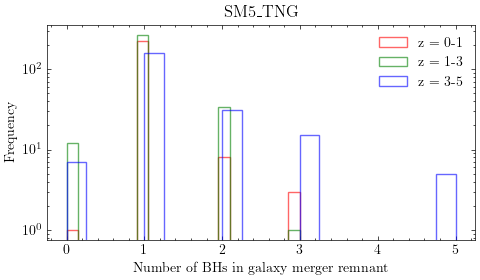

In [ ]:
NBH_mergers = fmergers_brahma['SubhaloLenType'][:,5,2]
Snapshot_mergers = fmergers_brahma['snaps'][:,2]
z_mergers = brahma_redshifts[Snapshot_mergers]

# Select a few redshift bins
z_bins = np.array([0, 1, 3, 5])
colors = ['r', 'g', 'b', 'm']

fig, ax = plt.subplots(figsize=(5,3))

for i in range(len(z_bins)-1):
    z_min, z_max = z_bins[i], z_bins[i+1]
    mask = (z_mergers >= z_min) & (z_mergers < z_max)
    
    ax.hist(NBH_mergers[mask], bins=20, alpha=0.6, 
            label=f'z = {z_min}-{z_max}', color=colors[i], histtype='step')

ax.set_xlabel('Number of BHs in galaxy merger remnant')
ax.set_ylabel('Frequency')
ax.set_title('SM5_TNG')
ax.legend()
#ax.grid(alpha=0.3)
ax.set_yscale('log')
plt.tight_layout()
plt.show()


In [ ]:
#find where the number of BHs in the merger remnant is greater than 100
find_ix_nbh_gtr_100 = np.where(NBH_mergers>100)[0]
snapshots_nbh_gtr_100 = Snapshot_mergers[find_ix_nbh_gtr_100]
redshifts_nbh_gtr_100 = brahma_redshifts[snapshots_nbh_gtr_100]
subhaloids_nbh_gtr_100 = fmergers_brahma['shids_subf'][:,2][find_ix_nbh_gtr_100]
print("Number of mergers with >100 BHs in remnant:", len(find_ix_nbh_gtr_100))

Number of mergers with >100 BHs in remnant: 0


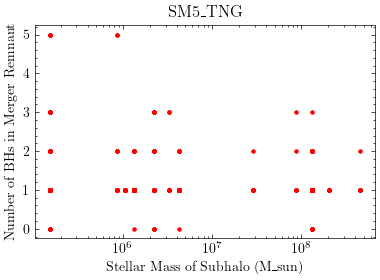

In [ ]:
subhalo_stellar_mass = []
for i in range(len(Snapshot_mergers)):
    stellar_mass = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=Snapshot_mergers[i],fields=['SubhaloMassType'])
    stellar_mass_nbh = stellar_mass[Snapshot_mergers[i],4] * 1e10 / h
    subhalo_stellar_mass.append(stellar_mass_nbh)


fig, ax = plt.subplots(figsize=(4,3))
ax.scatter(subhalo_stellar_mass, NBH_mergers, color='r',s=5)
ax.set_xlabel('Stellar Mass of Subhalo (M_sun)')
ax.set_ylabel('Number of BHs in Merger Remnant')
ax.set_title('SM5_TNG')
ax.set_xscale('log')
plt.tight_layout()
plt.show()

#### Since there are a lot of wandering BHs in the DF run, we can just check the most massive BH 

In [21]:
basePath ='/orange/lblecha/aklantbhowmick/GAS_BASED_SEED_MODEL_UNIFORM_RUNS/L12p5n512/AREPO/SM5_DFD_3_TNG/'
merger_file_path='/home/pranavsatheesh/host_galaxies/data/merger_files'
minN_values = [0,0,10,1]
merger_file_name = f'/galaxy-mergers_brahma_{basePath.split("/")[-2]}_gas-{minN_values[0]:03d}_dm-{minN_values[1]:03d}_star-{minN_values[2]:03d}_bh-{minN_values[3]:03d}.hdf5'
merger_file_loc='/home/pranavsatheesh/host_galaxies/data/merger_files'
merger_file_path = merger_file_loc + merger_file_name
fmergers_brahma = h5py.File(merger_file_path, 'r')
brahma_snapshots,brahma_redshifts = arepo.get_snapshot_redshift_correspondence(basePath)

In [22]:
NBH_mergers = fmergers_brahma['SubhaloLenType'][:,5,2]
Snapshot_mergers = fmergers_brahma['snaps'][:,2]
Subhaloid_mergers = fmergers_brahma['shids_subf'][:,2]
z_mergers = brahma_redshifts[Snapshot_mergers]

#find where the number of BHs in the merger remnant is greater than 100
find_ix_nbh_gtr_100 = np.where(NBH_mergers>100)[0]
snapshots_nbh_gtr_100 = Snapshot_mergers[find_ix_nbh_gtr_100]
redshifts_nbh_gtr_100 = brahma_redshifts[snapshots_nbh_gtr_100]
subhaloids_nbh_gtr_100 = fmergers_brahma['shids_subf'][:,2][find_ix_nbh_gtr_100]

In [ ]:
from scipy.spatial.distance import cdist

In [ ]:
# Find closest z_mergers to target redshifts
target_z = np.array([0, 1, 2, 3, 5, 7])
results = {}

for z_target in target_z:
    # Find the index of the closest z_mergers value
    closest_idx = np.argmin(np.abs(z_mergers - z_target))
    closest_z = z_mergers[closest_idx]
    results[z_target] = {'closest_z': closest_z, 'index': closest_idx}

In [ ]:
results

{0: {'closest_z': 2.220446049250313e-16, 'index': 0},
 1: {'closest_z': 0.9972942257819404, 'index': 2},
 2: {'closest_z': 2.0020281392528516, 'index': 5},
 3: {'closest_z': 3.008131071630377, 'index': 1},
 5: {'closest_z': 4.995933468164624, 'index': 7},
 7: {'closest_z': 7.005417045544533, 'index': 30}}

offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there


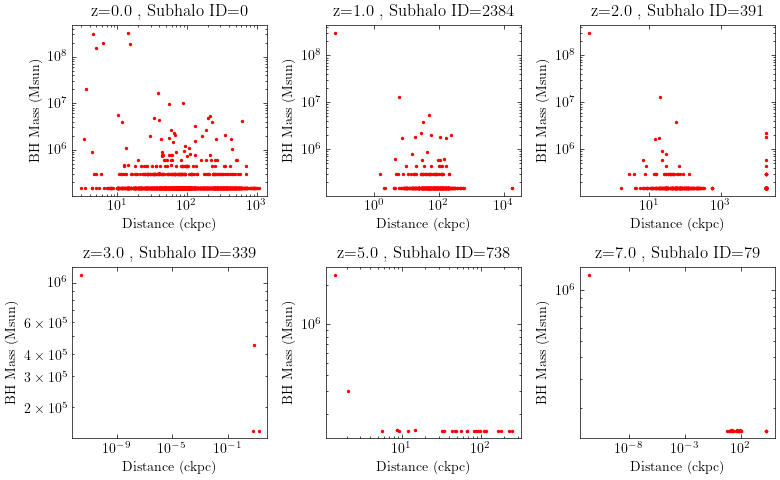

In [ ]:
fig,ax = plt.subplots(2,3,figsize=(8,5))
for i in range(6):
    z_target = target_z[i]
    closest_idx = results[z_target]['index']
    closest_z = results[z_target]['closest_z']
    snapshot_id = Snapshot_mergers[closest_idx]
    subhalo_id = Subhaloid_mergers[closest_idx]

    subhalo_data = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=snapshot_id,fields=['SubhaloLenType','SubhaloPos','SubhaloGrNr'])
    subhalo_center = subhalo_data['SubhaloPos'][subhalo_id] #ckpc

    MBH_coordinates = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['Coordinates'],p_type=5,desired_redshift=closest_z,subhalo_index=subhalo_id,group_type='subhalo')
    MBH_masses = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['BH_Mass'],p_type=5,desired_redshift=closest_z,subhalo_index=subhalo_id,group_type='subhalo')

    MBH_distance_from_center = cdist(MBH_coordinates[0], subhalo_center.reshape(1, -1))/h #ckpc
    BH_masses_in_subhalo = MBH_masses[0] * 1e10/h #Msun

    ax[i//3, i%3].scatter(MBH_distance_from_center, BH_masses_in_subhalo, color='r',s=2)
    ax[i//3, i%3].set_xscale('log',base=10)
    ax[i//3, i%3].set_yscale('log',base=10)
    ax[i//3, i%3].set_xlabel("Distance (ckpc)")
    ax[i//3, i%3].set_ylabel("BH Mass (Msun)")
    ax[i//3, i%3].set_title(f"z={closest_z:.1f} , Subhalo ID={subhalo_id}")

plt.tight_layout()

In [ ]:
index = 4
snapshot_id = snapshots_nbh_gtr_100[index]
redshift = redshifts_nbh_gtr_100[index]
subhalo_id = subhaloids_nbh_gtr_100[index]
subhalo_data = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=snapshot_id,fields=['SubhaloLenType','SubhaloPos','SubhaloGrNr'])
subhalo_center = subhalo_data['SubhaloPos'][subhalo_id] #ckpc

MBH_coordinates = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['Coordinates'],p_type=5,desired_redshift=redshifts_nbh_gtr_100[index],subhalo_index=subhaloids_nbh_gtr_100[index],group_type='subhalo')
MBH_masses = arepo.get_particle_property_within_postprocessed_groups(basePath,particle_property=['BH_Mass'],p_type=5,desired_redshift=redshifts_nbh_gtr_100[index],subhalo_index=subhaloids_nbh_gtr_100[index],group_type='subhalo')

MBH_distance_from_center = cdist(MBH_coordinates[0], subhalo_center.reshape(1, -1))/h #ckpc
BH_masses_in_subhalo = MBH_masses[0] * 1e10/h #Msun

offsets were already there
offsets were already there


Text(0, 0.5, 'BH Mass (Msun)')

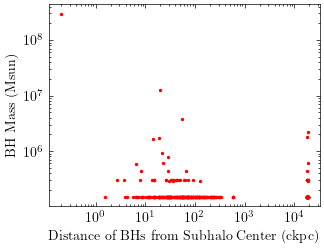

In [ ]:
plt.scatter(MBH_distance_from_center, BH_masses_in_subhalo, color='r',s=2)
plt.xscale('log',base=10)
plt.yscale('log',base=10)
plt.xlabel("Distance of BHs from Subhalo Center (ckpc)")
plt.ylabel("BH Mass (Msun)")

In [ ]:
subhalo_data = il_brahma.groupcat.loadSubhalos_postprocessed(basePath,snapNum=snapshot_id,fields=['SubhaloLenType','SubhaloHalfmassRadType'])

### BHS versus distance from subhalo center

In [49]:
# Prepare data for both simulations
def extract_merger_data(merger_file_obj, redshifts_arr):
    """Extract merger data from HDF5 file"""
    NBH_mergers = merger_file_obj['SubhaloLenType'][:,5,2]
    Snapshot_mergers = merger_file_obj['snaps'][:,2]
    Subhaloid_mergers = merger_file_obj['shids_subf'][:,2]
    z_mergers = redshifts_arr[Snapshot_mergers]
    return NBH_mergers, Snapshot_mergers, Subhaloid_mergers, z_mergers

# Get data for both simulations
NBH_sm5, Snap_sm5, Subhalo_sm5, z_sm5 = extract_merger_data(brahma_sm5, brahma_redshifts)
NBH_sm5_lw10, Snap_sm5_lw10, Subhalo_sm5_lw10, z_sm5_lw10 = extract_merger_data(brahma_sm5_lw10, brahma_redshifts)

In [50]:
# Create plots for both simulations
from scipy.spatial.distance import cdist

target_z = np.array([0, 1, 2, 3, 5, 7])

def create_mbh_distance_plot(ax_grid, NBH_mergers, Snapshot_mergers, Subhaloid_mergers, z_mergers, 
                            basePath, sim_name):
    """Create a 2x3 subplot showing BH distance distributions at different redshifts"""
    
    # Find closest z_mergers to target redshifts
    results = {}
    for z_target in target_z:
        closest_idx = np.argmin(np.abs(z_mergers - z_target))
        closest_z = z_mergers[closest_idx]
        results[z_target] = {'closest_z': closest_z, 'index': closest_idx}
    
    h = brahma_sm5.attrs['hubbleParam']
    
    for i in range(6):
        z_target = target_z[i]
        closest_idx = results[z_target]['index']
        closest_z = results[z_target]['closest_z']
        snapshot_id = Snapshot_mergers[closest_idx]
        subhalo_id = Subhaloid_mergers[closest_idx]

        subhalo_data = il_brahma.groupcat.loadSubhalos_postprocessed(basePath, snapNum=snapshot_id, 
                                                                      fields=['SubhaloLenType','SubhaloPos','SubhaloGrNr'])
        subhalo_center = subhalo_data['SubhaloPos'][subhalo_id]  # ckpc

        MBH_coordinates = arepo.get_particle_property_within_postprocessed_groups(basePath, particle_property=['Coordinates'], 
                                                                                   p_type=5, desired_redshift=closest_z, 
                                                                                   subhalo_index=subhalo_id, group_type='subhalo')
        MBH_masses = arepo.get_particle_property_within_postprocessed_groups(basePath, particle_property=['BH_Mass'], 
                                                                              p_type=5, desired_redshift=closest_z, 
                                                                              subhalo_index=subhalo_id, group_type='subhalo')

        MBH_distance_from_center = cdist(MBH_coordinates[0], subhalo_center.reshape(1, -1)) / h  # ckpc
        BH_masses_in_subhalo = MBH_masses[0] * 1e10 / h  # Msun

        ax_grid[i//3, i%3].scatter(MBH_distance_from_center, BH_masses_in_subhalo, color='r', s=2)
        ax_grid[i//3, i%3].set_xscale('log', base=10)
        ax_grid[i//3, i%3].set_yscale('log', base=10)
        ax_grid[i//3, i%3].set_xlabel("Distance (ckpc)")
        ax_grid[i//3, i%3].set_ylabel("BH Mass (Msun)")
        ax_grid[i//3, i%3].set_title(f"z={closest_z:.1f} , Subhalo ID={subhalo_id}")

offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there


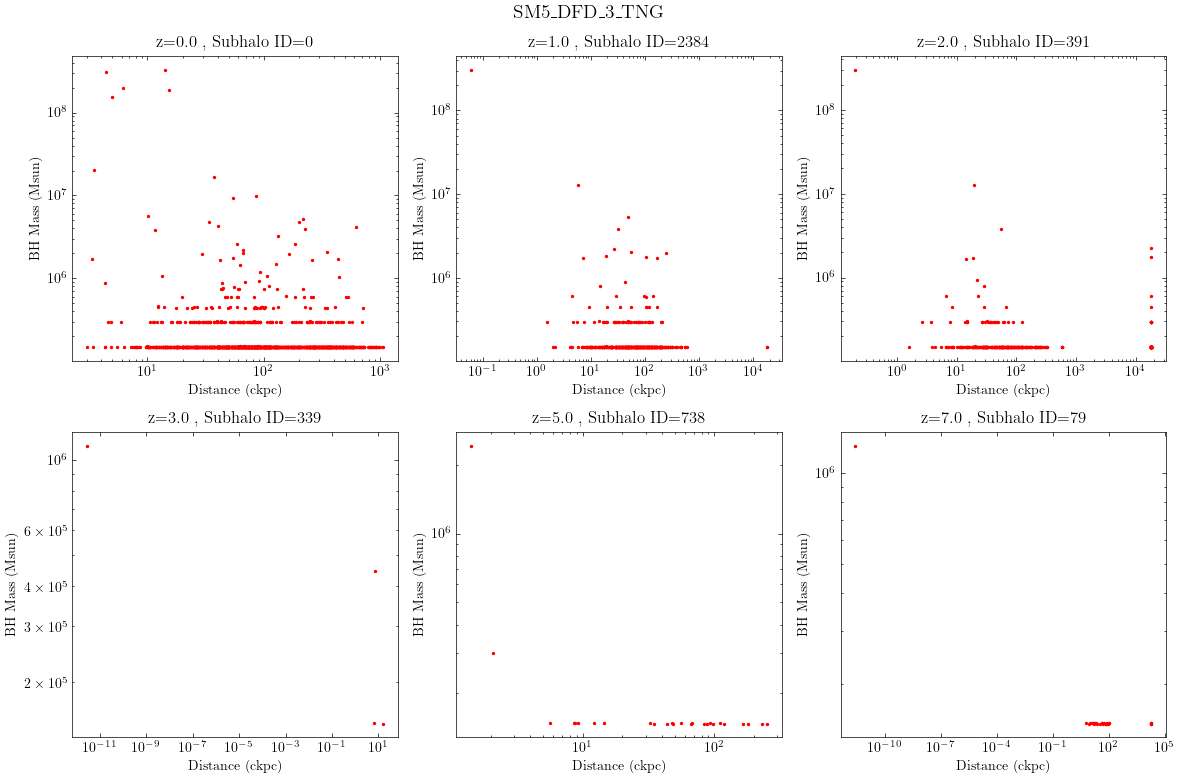

In [51]:
# Create plots for SM5_DFD_3_TNG
basePath_sm5 = brahma_sim_paths[0]
fig1, ax1 = plt.subplots(2, 3, figsize=(12, 8))
fig1.suptitle('SM5_DFD_3_TNG', fontsize=14)
create_mbh_distance_plot(ax1, NBH_sm5, Snap_sm5, Subhalo_sm5, z_sm5, basePath_sm5, 'SM5_DFD_3_TNG')
plt.tight_layout()
plt.show()

offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there
offsets were already there


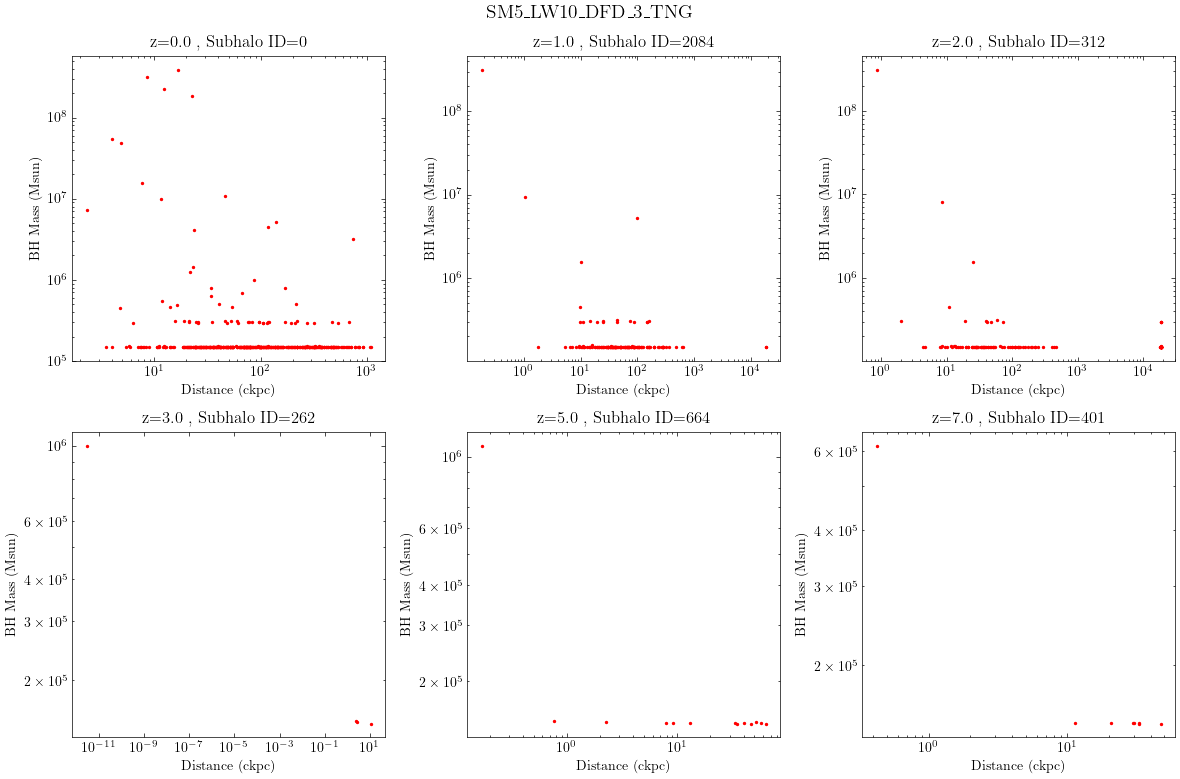

In [52]:
# Create plots for SM5_LW10_DFD_3_TNG
basePath_sm5_lw10 = brahma_sim_paths[1]
fig2, ax2 = plt.subplots(2, 3, figsize=(12, 8))
fig2.suptitle('SM5_LW10_DFD_3_TNG', fontsize=14)
create_mbh_distance_plot(ax2, NBH_sm5_lw10, Snap_sm5_lw10, Subhalo_sm5_lw10, z_sm5_lw10, basePath_sm5_lw10, 'SM5_LW10_DFD_3_TNG')
plt.tight_layout()
plt.show()